# GeoWatch — Phase 8: Real Sentinel-2 Imagery via Earth Search

Demonstrates the first optical-imagery provider: `Sentinel2Provider`
(`src/ingestion/sentinel2.py`), backed by
[Earth Search](https://earth-search.aws.element84.com/v1) — Element84's
free, public STAC API on AWS.

**This is different from every other external source GeoWatch uses:
it requires zero authentication.** No API key, no registration, no
`.env` setup — Earth Search's catalog and its backing Sentinel-2
Cloud-Optimized GeoTIFFs (COGs) are fully public. If you have a network
connection, the live-query cells below should work immediately.

Pipeline demonstrated:

```
Sentinel2Provider.search_observations() -> STAC scenes (metadata only, no pixels)
    -> pick a scene
    -> Sentinel2Provider.read_scene_bands() -> real NIR/RED/SWIR pixels for your AOI
       (reads directly from the COG over HTTP -- no full-file download)
    -> normalize_band() -> compute_ndvi() / compute_nbr() -> real vegetation/burn analysis
```


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from datetime import datetime, timedelta, timezone

import numpy as np
import matplotlib.pyplot as plt

from src.geospatial.aoi import AOI
from src.ingestion.sentinel2 import Sentinel2Provider, Sentinel2Error
from src.preprocessing.imagery import RasterReadError
from src.remote_sensing.spectral import normalize_band
from src.remote_sensing.ndvi import compute_ndvi
from src.remote_sensing.nbr import compute_nbr


## 1. Define an AOI and search for real scenes

No hardcoded region — same principle as every other GeoWatch provider.
This example searches over part of Zimbabwe/Zambia, but any bbox works.

In [2]:
aoi = AOI(label="Zimbabwe/Zambia demo AOI", west=28.5, south=-18.5, east=29.5, north=-17.5)

provider = Sentinel2Provider()

end = datetime.now(timezone.utc)
start = end - timedelta(days=60)  # widen the window -- cloud-free scenes aren't every day

try:
    scenes = provider.search_observations(
        bbox=aoi.as_bbox_tuple(),
        start_date=start,
        end_date=end,
        max_cloud_cover=20.0,  # skip cloudy scenes
        limit=5,
    )
    print(f"Found {len(scenes)} scene(s) in the last 60 days with <20% cloud cover.")
    for s in scenes:
        print(f"  {s['id']}  |  {s['properties']['datetime']}  |  "
              f"cloud cover: {s['properties'].get('eo:cloud_cover', '?'):.1f}%")
    live_data_available = len(scenes) > 0
except Sentinel2Error as exc:
    print(f"Live search failed ({exc}) -- this notebook environment may not have network access.")
    print("Falling back to a labeled synthetic scene for the rest of this notebook.")
    live_data_available = False


Live search failed (Earth Search query failed: 403 Client Error: Forbidden for url: https://earth-search.aws.element84.com/v1/search) -- this notebook environment may not have network access.
Falling back to a labeled synthetic scene for the rest of this notebook.


## 2. Read real pixels for the AOI (or fall back honestly)

If a live scene was found, this reads real NIR/RED/SWIR16 pixels
directly from the COG — no download of the full ~100MB+ band files,
just the AOI's window. If live data wasn't available (no network, or
no cloud-free scene in range), this falls back to a small
**synthetic** array, clearly labeled as such — never silently
pretending fake data is real.

In [3]:
if live_data_available:
    scene = scenes[0]
    try:
        bands_dn = provider.read_scene_bands(scene, ["red", "nir", "swir16"], aoi)
        print(f"Read real pixels from scene {scene['id']}:")
        for band, arr in bands_dn.items():
            print(f"  {band}: shape={arr.shape}, dtype={arr.dtype}, "
                  f"min={arr.min()}, max={arr.max()}, mean={arr.mean():.1f}")
        data_source_note = f"REAL Sentinel-2 imagery (scene {scene['id']})"
    except RasterReadError as exc:
        print(f"Real read failed ({exc}); falling back to synthetic data.")
        live_data_available = False

if not live_data_available:
    rng = np.random.default_rng(3)
    size = 80
    bands_dn = {
        "red": (rng.normal(800, 50, (size, size))).clip(0, 10000).astype(np.uint16),
        "nir": (rng.normal(3200, 100, (size, size))).clip(0, 10000).astype(np.uint16),
        "swir16": (rng.normal(1400, 80, (size, size))).clip(0, 10000).astype(np.uint16),
    }
    data_source_note = "SYNTHETIC (labeled) -- no live scene available in this run"

print(f"\nData source for this notebook run: {data_source_note}")



Data source for this notebook run: SYNTHETIC (labeled) -- no live scene available in this run


## 3. Normalize DN -> reflectance, then run real GeoWatch analysis

This is where Sentinel-2 imagery joins the exact same NDVI/NBR engine
built in Milestone 1 — the whole point of the provider abstraction.
Whether the pixels came from real Earth Search data or the synthetic
fallback above, everything from here on is real, tested GeoWatch code.

**Note:** `read_scene_bands()` automatically resamples every requested band to a common pixel grid (10m by default). This matters because Sentinel-2's bands are not all the same native resolution — RED/NIR are 10m, but SWIR16 is natively 20m. Without this, NDVI/NBR calculations below would fail with a shape-mismatch error (a real bug caught during development by a live query against actual Sentinel-2 data, not by testing against same-resolution synthetic files alone).

In [4]:
red = normalize_band(bands_dn["red"])
nir = normalize_band(bands_dn["nir"])
swir16 = normalize_band(bands_dn["swir16"])

ndvi = compute_ndvi(nir, red)
nbr = compute_nbr(nir, swir16)

print(f"NDVI: mean={np.nanmean(ndvi):.3f}, min={np.nanmin(ndvi):.3f}, max={np.nanmax(ndvi):.3f}")
print(f"NBR:  mean={np.nanmean(nbr):.3f}, min={np.nanmin(nbr):.3f}, max={np.nanmax(nbr):.3f}")


NDVI: mean=0.600, min=0.522, max=0.677
NBR:  mean=0.391, min=0.292, max=0.508


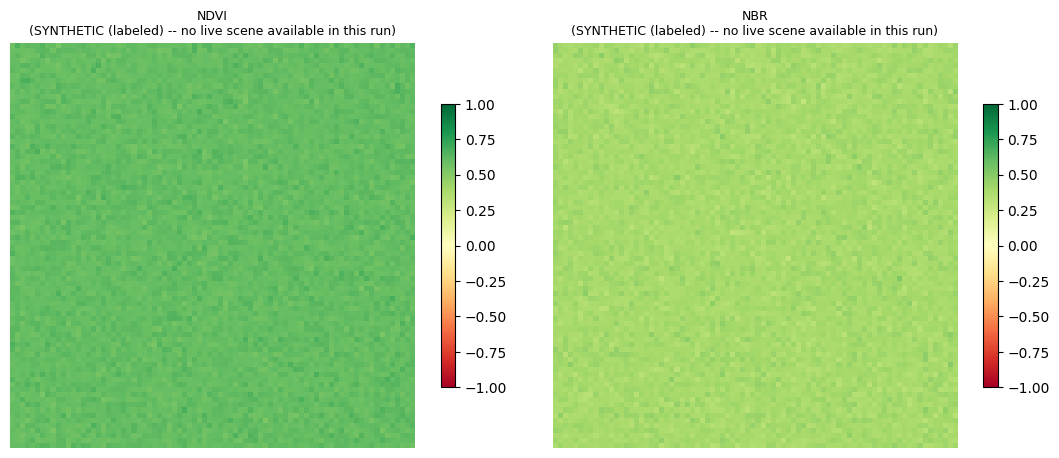

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title(f"NDVI\n({data_source_note})", fontsize=9)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].imshow(nbr, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title(f"NBR\n({data_source_note})", fontsize=9)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], shrink=0.7)

plt.tight_layout()
plt.show()


## What this unlocks

With a real optical-imagery provider in place, two things that were
previously engine-only (validated on synthetic data because there was
no live source) can now genuinely go live:

- **Wildfire detection** (`src/detection/wildfire.py`) on a real
  pre/post-fire Sentinel-2 pair for an actual AOI.
- **Vegetation decline** (`src/detection/vegetation.py`) on real NDVI
  computed from real imagery — this is the missing piece that was
  keeping vegetation monitoring out of the live dashboard.

Neither is wired into the dashboard yet — that's the natural next step,
following the same pattern FIRMS did: prove the provider works here
first, then build the ingestion -> event -> dashboard pipeline on top
of it.